# Spotify Dataset Analysis
## Description
 This project works with a subset of the Spotify dataset created by [Luan Moura, Emanuel Fontelles, Vinicius Sampaio, and Mardônio França](https://data.mendeley.com/datasets/3t9vbwxgr5/3), which includes information about tracks with the following features (columns):

 - **track_id**: Track identification number (unique in the dataset).
 - **artist_name**: The name of the artist or the band.
 - **track_name**: The title of the track.
 - **release_date**: Year in which the track was released.
 - **genre**: Musical genre.
 - **sadness**: How sad sounds the track based on its `valence` value.
 - **danceability**: How suitable a track is for dancing, based on a blend of musical elements such as tempo, rhythm stability, beat strength, and overall regularity. Higher values suggest a more dance-friendly track.
 - **topic**: Main theme or subject that characterizes the song.
 - **loudness**: Average loudness in decibels (dB) across the entire track;
 - **acousticness**: Presence of acoustic instruments.
 - **instrumentalness**: Describes whether a track contains fewer vocals or not;
 - **valence**: Measures the musical positiveness of a track.
 - **energy**: Perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy.

In [1]:
import otter
grader = otter.Notebook("spotify-dataset-analysis.ipynb")

## Question 1: Collect and prepare your data

Write a code that follows these instructions in the specified order:  

1. Read the data from the file `spotify_data_assignment2.csv` into a DataFrame object named `df`. Use a semicolon (`;`) as a separator.
2. Rename the DataFrame column `release_date` to `release_year`.
3. Drop the Dataframe columns `instrumentalness`, `loudness`, and `valence`.
4. Transform the `energy` column to percentages (e.g., 0.933932 -> 93). You can use the `.round()` function to round values in a DataFrame column. 
5. Save the resulting DataFrame in a file named `new_spotify_data_assignment2.csv`, using a semicolon as separator (`;`). Do not include the index.
6. Display 5 random rows of your DataFrame `df`.  

In [2]:
import pandas as pd

df = pd.read_csv('spotify_data_assignment2.csv', sep=';') # read data from csv file
df = df.rename(columns={'release_date': 'release_year'}) # rename release_date column to release_year

df = df.drop(columns=['instrumentalness', 'loudness', 'valence']) # remove columns
df['energy'] = (df['energy'] * 100).round() # convert energy column to % using .round()

df.to_csv('output/new_spotify_data_assignment2.csv', sep=';', index=False) # save results to new csv file

df.sample(5) # display random rows using .sample()

,track_id,artist_name,track_name,release_year,genre,sadness,danceability,topic,acousticness,energy
555,t555,george ezra,blame it on me,2015,pop,0.281265,0.516950,night/time,0.471887,76.0
3681,t3681,katastro,voodoo,2018,reggae,0.000634,0.698906,obscene,0.043373,79.0
4764,t4764,marc reis,new kid on the block,2015,hip hop,0.102037,0.663165,violence,0.145581,65.0
4616,t4616,goin' through,the showcase (i vitrina),2012,hip hop,0.456779,0.781220,sadness,0.060340,64.0
2432,t2432,the coasters,sweet georgia brown,2019,blues,0.001698,0.662082,romantic,0.512048,35.0


In [3]:
grader.check("q1")

q1 results: All test cases passed!
q1 - 1 message: Great! Your code passed this test.

## Question 2: Understanding the structure of your data 

Based on the DataFrame `df` resulting from the transformations in Question 1, answer the following questions: 

- 2a) How many tracks are in the dataset?
- 2b) How many attributes are used to describe each track? Could you print the column names?
- 2c) What is the range of indices in the dataset?
- 2d) Which columns contain numeric values? 
- 2e) Are there any missing values in the dataset? If so, indicate which columns have missing values.
- 2f) What is the difference between the `df` object and the result of `df['artist_name']`?
 
You can add your answers in the comments below. **Support all your answers with code.** Do not repeat the same code for more than one answer.

In [4]:
#2a) How many tracks are in the dataset?
# There are 5213 tracks in the data set. This information is retrieved using the len() function

df = pd.read_csv('output/new_spotify_data_assignment2.csv', sep=';') # read data from csv file
num_tracks = len(df)
num_tracks

5213

In [5]:
#2b) How many attributes are used to describe each track? Could you print the column names?
# There are 10 attributes that describe each track

print(f'Attributes: {len(df.columns)}') # get number of columns
df.columns.tolist() # print column names as a list

Attributes: 10


['track_id',
 'artist_name',
 'track_name',
 'release_year',
 'genre',
 'sadness',
 'danceability',
 'topic',
 'acousticness',
 'energy']

In [6]:
#2c) What is the range of indices in the dataset?
# The indices range from 0 to 5212

print(f'The indices range from {df.index.min()} to {df.index.max()}')
print(f'Index start: {df.index.min()}')
print(f'Index end: {df.index.max()}')

The indices range from 0 to 5212
Index start: 0
Index end: 5212


In [7]:
#2d) Which columns contain numeric values? 
# Columns with numeric values: release_year, sadness, danceability, acousticness and energy

df.select_dtypes(include='number').sample(5) # return columns with the dtype `number`

,release_year,sadness,danceability,acousticness,energy
3081,2018,0.000554,0.625257,0.152610,57.0
983,2018,0.117311,0.731398,0.805221,41.0
1593,2018,0.099133,0.493122,0.015360,81.0
3393,2014,0.000810,0.744395,0.411646,58.0
1215,2013,0.001504,0.749810,0.572289,41.0


In [8]:
#2e) Are there any missing values in the dataset? If so, indicate which columns have missing values.

# No, there are no missing values in the dataset
# I can spot missing values in the dataset when a cell says NaN

df.isnull().sum() # get the total number of missing values

track_id        0
artist_name     0
track_name      0
release_year    0
genre           0
sadness         0
danceability    0
topic           0
acousticness    0
energy          0
dtype: int64

In [9]:
#2f) What is the difference between the `df` object and the result of `df['artist_name']`?

# `df` is a dataframe that contains all columns and rows
# `df['artist_name']` is a series that only contains values from the artist_name column

print(f"Type of df: {type(df)}") # get type of df
print(f"Type of df['artist_name']: {type(df['artist_name'])}") # get type of df['artist_name']

Type of df: <class 'pandas.core.frame.DataFrame'>
Type of df['artist_name']: <class 'pandas.core.series.Series'>


<!-- END QUESTION -->

## Question 3: Understanding your data values

Based on the DataFrame `df` obtained in Question 1, answer the following questions: 

- 3a) What is the highest `danceability` value among all tracks?
- 3b) What is the range of `sadness` values?
- 3c) In which years were the first quarter of tracks released?
- 3d) What is the average `energy` value in the dataset?
 
You can add your answers in the comments below. Support all your answers with code. You can repeat code statements here.

In [10]:
#3a) What is the highest `danceability` value among all tracks?
# The highest danceability value among all tracks is 0.9783385681793566

highest_danceability = df['danceability'].max() # get max value in danceability column
print(f'The highest danceability value among all tracks is: {highest_danceability}')


The highest danceability value among all tracks is: 0.9783385681793566


In [11]:
#3b) What is the range of `sadness` values?

# The range of sadness values is from 0.0002907822237498 to 0.8655792869268175
# with a range of 0.8652885047030677

min_sadness = df['sadness'].min() # get minimum value in sadness column
max_sadness = df['sadness'].max() # get maximum value in sadness column
sad_range = max_sadness - min_sadness # range = max - min

print('Range of sadness values:')

print(f'Minimum: {min_sadness}')
print(f'Maximum: {max_sadness}')
print(f'Range: {sad_range}')

Range of sadness values:
Minimum: 0.0002907822237498
Maximum: 0.8655792869268175
Range: 0.8652885047030677


In [12]:
#3c) In which years were the first quarter of the tracks released?

first_quart = int(len(df) * 0.25) # get first 25% of entries

# sort by release year (lowest to highest), and use .head() to show first quarter
first_quarter_year = df.sort_values(by='release_year', ascending=True).head(first_quart)

years =  first_quarter_year['release_year'].unique() # only get specific years tracks were released
print(f'The first quarter of the tracks released in: {years}')

release_count = first_quarter_year['release_year'].value_counts().sort_index() # get number of releases per year

print('Releases per year:')
release_count

The first quarter of the tracks released in: [2011 2012 2013]
Releases per year:


release_year
2011    531
2012    588
2013    184
Name: count, dtype: int64

In [13]:
#3d) What is the average `energy` value in the dataset?
# The average energy value in the dataset is 66.43909457126415

avg_energy = df['energy'].mean() # get the mean (average) value of energy column
print(f'Average energy value in dataset: approx. {avg_energy.round(2)}%') # round number to 2 decimal places
print(f'Exact value: {avg_energy}')

Average energy value in dataset: approx. 66.44%
Exact value: 66.43909457126415


<!-- END QUESTION -->

## Question 4: Getting information from your data: Best Tracks for Dancing. 
What are the 10 most suitable tracks for dancing? 
  - Assign the resulting DataFrame to a variable named `df4`. 
  - Display the resulting DataFrame.
  - Respond to the question by listing the track names in a comment below. You can just answer this by coding or just by looking at the result shown in the previous step. 

In [14]:
# sort by danceability (highest to lowest), and use .head() to show first 10
df4 = df.sort_values(by='danceability', ascending=False).head(10)
print('Top 10 Most Suitable Tracks for Dancing:')
df4 # display the dataframe

Top 10 Most Suitable Tracks for Dancing:


,track_id,artist_name,track_name,release_year,genre,sadness,danceability,topic,acousticness,energy
878,t878,selena gomez,bad liar,2017,pop,0.077599,0.978339,obscene,0.189758,41.0
3324,t3324,fortunate youth,melody,2013,reggae,0.002105,0.976172,world/life,0.541164,45.0
4940,t4940,machine gun kelly,trap paris,2017,hip hop,0.001422,0.976172,obscene,0.022891,65.0
5173,t5173,run–d.m.c.,it's tricky,2019,hip hop,0.001754,0.970757,obscene,0.001425,88.0
4778,t4778,timbaland & magoo,drop,2015,hip hop,0.000892,0.968591,obscene,0.480923,57.0
5109,t5109,mc hammer,let's get it started,2019,hip hop,0.001880,0.968591,obscene,0.056626,72.0
5053,t5053,lil baby,yes indeed,2018,hip hop,0.001645,0.968591,obscene,0.036043,35.0
1564,t1564,katie noel,diesel gang,2018,country,0.000627,0.961009,obscene,0.131525,54.0
4801,t4801,clemens,hop rundt,2015,hip hop,0.001224,0.959926,violence,0.142569,88.0
5174,t5174,young mc,bust a move,2019,hip hop,0.004785,0.957760,world/life,0.051405,77.0


In [15]:
#Respond to the question by listing the track names in a comment below. You can answer this by coding or just by looking at the result displayed in the previous step.

# The 10 most suitable tracks for dancing:
# - bad liar, selena gomez
# - melody, fortunate youth
# - trap paris, machine gun kelly
# - it's tricky, run–d.m.c.
# - drop, timbaland & magoo
# - let's get it started, mc hammer
# - yes indeed, lil baby
# - diesel gang, katie noel
# - hop rundt, clemens
# - bust a move, young mc

In [16]:
grader.check("q4")

q4 results: All test cases passed!
q4 - 1 message: Great! Your code passed the public tests.

## Question 5: Getting information from your data: Acoustic Rock Artists. 

Which artists have the top 10 rock tracks with the highest acousticness values?
  - The resulting DataFrame should include the 10 tracks, including only the track ID, artist name, track name, genre, and acousticness value. 
  - Assign the resulting DataFrame to a variable named `df5`. 
  - Display the resulting DataFrame. 
  - Respond to the question by listing the authors in a comment. You can just answer this by coding or just by looking at the result shown in the previous step. 
  

In [17]:
rock_tracks = df[df['genre'] == 'rock'] # filter the genre column to only show rock

# sort by acousticness (highest to lowest), and use .head() to show first 10
df5 = (rock_tracks[['track_id', 'artist_name', 'track_name', 'genre', 'acousticness']] # only display these columns
       .sort_values(by='acousticness', ascending=False).head(10))

print('Top 10 Rock Tracks with Highest Acousticness:')
df5 # display the filtered dataframe

Top 10 Rock Tracks with Highest Acousticness:


,track_id,artist_name,track_name,genre,acousticness
4028,t4028,twenty one pilots,truce,rock,0.997992
4208,t4208,sufjan stevens,death with dignity,rock,0.989960
4370,t4370,john mayer,you're gonna live forever in me,rock,0.986948
3882,t3882,dave matthews band,sweet,rock,0.975904
4268,t4268,radiohead,daydreaming,rock,0.971888
3937,t3937,alt-j,hand-made,rock,0.968875
4514,t4514,the lumineers,donna,rock,0.963855
4506,t4506,the national,light years,rock,0.953815
4081,t4081,angel olsen,unfucktheworld,rock,0.946787
4316,t4316,sufjan stevens,visions of gideon,rock,0.945783


In [18]:
# Respond to the question by listing the authors below. 
# You can answer this by coding 
# or just by looking at the result shown in the previous step and listing the names in a comment. 

# answer displayed with code
print(f'Artists with the Top 10 Acoustic Rock Tracks:')

for artist in df5['artist_name']: # use a for loop to print every artist in df5
    print(f'- {artist.title()}') # capitalize artist names using .title()

Artists with the Top 10 Acoustic Rock Tracks:
- Twenty One Pilots
- Sufjan Stevens
- John Mayer
- Dave Matthews Band
- Radiohead
- Alt-J
- The Lumineers
- The National
- Angel Olsen
- Sufjan Stevens


In [19]:
grader.check("q5")

q5 results: All test cases passed!
q5 - 1 message: Great! Your code passed the public tests.

## Question 6: Getting information from your data: Sad tracks. 
How many sad tracks were released before 2017 by Imagine Dragons or One Direction? 

  - A track is considered sad if the sadness score is greater than 0.5. 
  - Select all sad tracks written before 2017 by `imagine dragons` or `one direction` from the data and assign the result to a variable named `df6`. 
  - Update `df6` by filtering the columns track id, artist name, track name, release year, and sadness value.
  - Display `df6` in the cell output. 
  - Respond to the question in a cell code below. You must use code to support your answer. 

In [20]:
# boolean expression breakdown - return values that satisfy:

# sadness is greater than 0.5
# release year is less than 2017
# arist name is imagine dragons OR one direction (using |)
df6 = df[(df['sadness'] > 0.5) &
         (df['release_year'] < 2017) &
         ((df['artist_name'] == 'imagine dragons') | (df['artist_name'] == 'one direction'))]

df6 = df6[['track_id', 'artist_name', 'track_name', 'release_year', 'sadness']] # only display these columns

print('Sad Tracks Released Before 2017 by Imagine Dragons or One Direction:')
df6 # display the filtered dataframe

Sad Tracks Released Before 2017 by Imagine Dragons or One Direction:


,track_id,artist_name,track_name,release_year,sadness
179,t179,one direction,stand up,2012,0.754363
391,t391,one direction,where do broken hearts go,2014,0.514833
503,t503,one direction,if i could fly,2015,0.559431
3887,t3887,imagine dragons,nothing left to say / rocks,2012,0.548904
3897,t3897,imagine dragons,selene,2012,0.566642


In [21]:
# Respond to the question in this cell code. You must use code to support your answer.

num_sad_tracks = len(df6) # get total number of sad tracks
print(f'Number of sad tracks released before 2017 by Imagine Dragons or One Direction: {num_sad_tracks}')

Number of sad tracks released before 2017 by Imagine Dragons or One Direction: 5


In [22]:
grader.check("q6")

q6 results: All test cases passed!
q6 - 1 message: Great! Your code passed the public tests.

## Question 7: Plotting your data: Tracks by genre. 

- Using the DataFrame `df` obtained in Question 1, plot the number of tracks by genre in a Pie Plot.
- Don't forget to add a title and the legend to your plot.
- Show the % that represents each category.

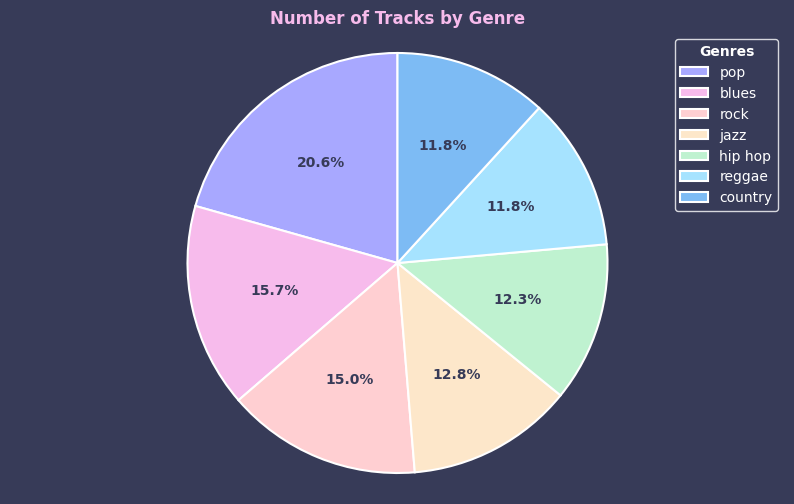

In [23]:
import matplotlib.pyplot as plt

genre_count = df['genre'].value_counts() # get number of tracks by genre

# create custom color palette
palette = ['#A8A8FF', '#f7bbec', '#FFCFD2', '#fde7ca', '#bff2d0', '#a6e3ff', '#7dbbf4']
bg_color = '#373b58'

# set size of the chart
plt.figure(figsize=(10,6), facecolor=bg_color)
plt.pie(genre_count, # use genre count as index
        startangle=90, # start the first slice at 90deg
        autopct='%1.1f%%', # display percentages with 1 decimal place
        colors=palette, # apply custom color palette
        center=(0,0), # center the chart
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}, # add border to pie slices
        textprops={'fontsize': 10, 'fontweight': 'bold', 'color': bg_color}) # text customization (font weight, size and color)

# add title and customize the style
plt.title('Number of Tracks by Genre', fontweight='bold', color=palette[1])

# add a legend and position the legend to the top right + customize style
legend = plt.legend(genre_count.index, title='Genres',
           loc='upper right',
           facecolor=bg_color, # legend bg color
           edgecolor='white', # legend border color
           labelcolor='white', # legend text color
           title_fontsize=10) # legend title font size

# set legend color and font weight to bold and white
legend.get_title().set_color('white')
legend.get_title().set_fontweight('bold')

# set font to monospace
plt.rcParams["font.family"] = "monospace"

plt.axis('equal') # set equal scaling (figsize=(10,6)
plt.show() # display the chart


<!-- END QUESTION -->

## Question 8: Plotting your data: 'World/Life' tracks

- Plot the number of 'world/life' tracks over the years.
- Use any plot suitable for this question (bar, barh, line, etc).  
- Make sure that the years are plotted in ascending order.
- Don't forget to add a title to your plot.

Text(0, 0.5, 'Number of Tracks')

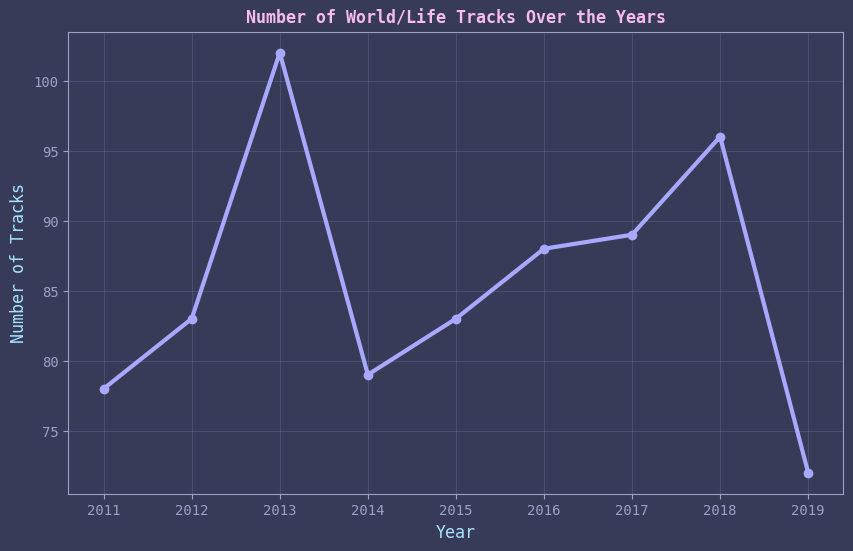

In [24]:
worldlife_tracks = df[df['topic'] == 'world/life'] # filter the topic column to only show world/life
tracks_per_year = worldlife_tracks['release_year'].value_counts().sort_index() # get number of tracks per year in ascending order

# color palette
chart_palette = ['#757ba9', '#9CA1C7']

# set size of the chart
plt.figure(figsize=(10,6), facecolor=bg_color)

# change chart background color
ax = plt.gca()
ax.set_facecolor(bg_color)
ax.tick_params(colors=chart_palette[1]) # set axis colors
plt.setp(ax.spines.values(), color=chart_palette[1]) # set border color

# plot type: line
plt.plot(tracks_per_year.index, tracks_per_year.values, # use tracks per year as index and chart values
         linewidth=3, # thick line width
         color=palette[0], # set line to purple
         marker='o') # add dots to each point

plt.grid(alpha=0.3, color=chart_palette[0]) # add grid to chart and make opacity 30%

# add title and customize the style (font weight, color)
plt.title('Number of World/Life Tracks Over the Years', fontweight='bold', color=palette[1])

# add x and y axis labels and customize the style (font size, color)
plt.xlabel('Year', fontsize=12, color=palette[5])
plt.ylabel('Number of Tracks', fontsize=12, color=palette[5])

<!-- END QUESTION -->

# E. Testing 
To double-check your work, the cell below will rerun all of the autograder tests.

In [25]:
grader.check_all()

q1 results: All test cases passed!
q1 - 1 message: Great! Your code passed this test.

q4 results: All test cases passed!
q4 - 1 message: Great! Your code passed the public tests.

q5 results: All test cases passed!
q5 - 1 message: Great! Your code passed the public tests.

q6 results: All test cases passed!
q6 - 1 message: Great! Your code passed the public tests.